In [12]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
from pathlib import Path
import os
from typing import Any, List, Optional, Tuple
import itertools

from smt.sampling_methods import LHS
from smt.surrogate_models import MixIntKernelType

from comcatalyst.vars.var_metadata import VarMetadata
from comcatalyst.vars.vars_metadata import VarsMetadata
from comcatalyst.xprs.fn_objectives import calc_gp_objective_01
from comcatalyst.xprs.xpr_moda import XPRModA, XPRModAHyperparams, XPRModAResultRunXpr
from comcatalyst.xprs.visualizations import (
    plot_ground_truth,
    plot_3d_ground_truth
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **Functions.**

In [6]:
def benchmark(
    fn_gp_objective: callable,
    vars_metadata: Any,
    z: Any,
    x_true_max: np.ndarray,
    y_true_max: float,
    seeds: List[int],
    fixed_hyperparams_dict: dict,
    varying_hyperparams_dict: List[Tuple[str, List[Any]]],
    save_dir: str,
    seed_ydoe_offset: int= 1000,
    max_n_iters: int = None,
    x_init: Optional[np.ndarray] = None,
    y_init: Optional[np.ndarray] = None,
) -> Tuple[list, int]:
 
    vh_names = [name for name, _ in varying_hyperparams_dict]
    vh_vals  = [vals for _, vals in varying_hyperparams_dict]

    save_dir_path_obj = Path(save_dir)
    save_dir_path_obj.mkdir(parents=True, exist_ok=True)
    json_path = save_dir_path_obj / "__results__.json"
 
    all_results: List[XPRModAResultRunXpr] = []
    vh_combos = list(itertools.product(*vh_vals))
    total = len(vh_combos) * len(seeds)

    run_id = 0
    
    print(f"\n--- Experiments for hyperparameters {vh_names} ---")

    for vh_combo in vh_combos:
        hyperparams_dict = {
            **fixed_hyperparams_dict,
            **dict(zip(vh_names, vh_combo))
        }

        hyperparams = XPRModAHyperparams(**hyperparams_dict)

        if (max_n_iters is not None) and (hyperparams.n_init + hyperparams.n_iter_bo > max_n_iters):
            hyperparams.n_iter_bo = max_n_iters - hyperparams.n_init

        for seed in seeds:
            
            print("\n", " "*2 + f"\n({run_id+1}/{total}) Running " +
                ", ".join(f"{n}={getattr(hyperparams, n)}" for n in vh_names) +
                f", seed={seed}...")
            
            result = XPRModA.run_xpr(
                fn_gp_objective=fn_gp_objective,
                vars_metadata=vars_metadata,
                z=z,
                x_true_max=x_true_max,
                y_true_max=y_true_max,
                hyperparams=hyperparams,
                seed=seed,
                seed_ydoe=seed+seed_ydoe_offset,
                x_init=x_init,
                y_init=y_init,
            )

            all_results.append(result)
            
            if json_path.exists():
                existing = json.loads(json_path.read_text())
            else:
                existing = []
            existing.append(result.to_json_dict())
            json_path.write_text(json.dumps(existing, indent=2))

            print("\n", " "*4, "Results:")
            XPRModA.print_opt_result(x=result.x_opt, y=result.y_opt, vars_metadata=vars_metadata, indent=8)
            print(" "*8 + f"x_gap={result.x_gap:.3f}, y_gap={result.y_gap:.3f}")
            
            run_id += 1

    print(f"Results saved in {save_dir}")
    return all_results

# **XPRModA.**

## **Support.**

In [ ]:
# Variables
vars_metadata = VarsMetadata([
    VarMetadata(name="x_qual1",  var_type="categorical", support=["A","B"]),
    VarMetadata(name="x_qual2",  var_type="categorical", support=["alpha","beta"]),
    VarMetadata(name="x_quant1", var_type="continuous",  support=(-1, 1)),
    VarMetadata(name="x_quant2", var_type="continuous",  support=(-1, 1)),
])

z = {"z1": 1.0, "z2": 1.0}

# Fonction objectif GP
fn_gp_objective = lambda x, vars_metadata, z, sigma_noise, rng=None: calc_gp_objective_01(
    x=x,
    vars_metadata=vars_metadata,
    z=z,
    sigma_noise=sigma_noise,
    rng=rng,
    _SCALE_Q1={0: 2, 1: 2},
    _SCALE_Q2={0: 2, 1: 2},
)

## **Ground truth.**

  x* = x_qual1 = A / x_qual2 = alpha / x_quant1 = 0.4935 / x_quant2 = 0.9980
  y* = 5.2992


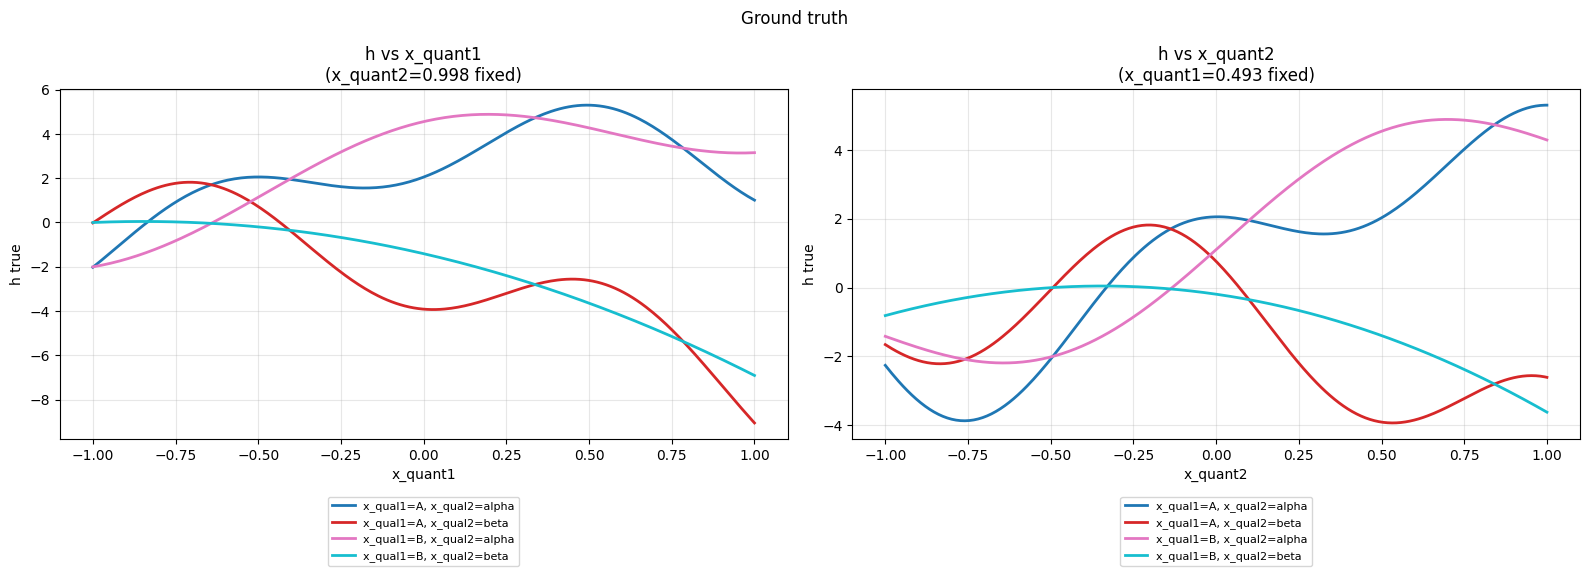

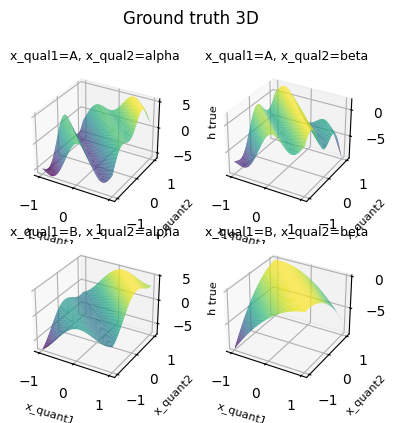

In [8]:
# True max
x_true_max, y_true_max, _, _ = XPRModA.calc_true_max(
    fn_gp_objective=fn_gp_objective, 
    vars_metadata=vars_metadata, 
    z=z, 
    n_grille=1000
)

XPRModA.print_opt_result(x=x_true_max, y=y_true_max, vars_metadata=vars_metadata)

# Plot true max 2d
plot_ground_truth(
    fn_gp_objective=fn_gp_objective,
    vars_metadata=vars_metadata,
    z=z,
    quant_fixed_vals=(
        (2, x_true_max[2]), 
        (3, x_true_max[3])
    ),
    n_points=300,
    figsize=(8,6)
)

# PLot true max 3d
plot_3d_ground_truth(
    fn_gp_objective=fn_gp_objective,
    vars_metadata=vars_metadata,
    z=z,
    quant_idx_1=2,
    quant_idx_2=3,
    n_points=300,
    n_cols=2,
    figsize=(2,2)
)


## **Benchmark.**

In [ ]:
# Fixed hyperparams
fixed_hyperparams_dict = {
    "sampling_method": LHS,
    "sampling_criterion": "ese",
    "qei": "KBLB",
    "n_start": 20,
    }

# varying hyperparams
varying_hyperparams_dict = [
    ("n_init", [2, 6, 10, 14]),
    ("n_iter_bo", [30]),
    ("sigma_noise", [0.1, 1.0]),
    ("bo_criterion", ["EI", "LCB"]),
    ("kernel", [MixIntKernelType.CONT_RELAX])
]

seeds = list(range(0,30))

results = benchmark(
    fn_gp_objective=fn_gp_objective,
    vars_metadata=vars_metadata,
    z=z,
    x_true_max=x_true_max,
    y_true_max=y_true_max,
    seeds=seeds,
    fixed_hyperparams_dict=fixed_hyperparams_dict,
    varying_hyperparams_dict=varying_hyperparams_dict,
    save_dir=os.path.join(os.getcwd(), "..", "data", "xpr_moda_benchmark"),
    max_n_iters=30,
)


--- Experiments for hyperparameters ['n_init', 'n_iter_bo', 'sigma_noise', 'bo_criterion', 'kernel'] ---

   
(1/80) Running n_init=2, n_iter_bo=28, sigma_noise=0.1, bo_criterion=EI, kernel=MixIntKernelType.CONT_RELAX, seed=45...

      Results:
        x* = x_qual1 = A / x_qual2 = alpha / x_quant1 = 1.0000 / x_quant2 = 0.4600
        y* = 5.2494
        x_gap=0.131, y_gap=0.050

   
(2/80) Running n_init=2, n_iter_bo=28, sigma_noise=0.1, bo_criterion=EI, kernel=MixIntKernelType.CONT_RELAX, seed=46...

      Results:
        x* = x_qual1 = A / x_qual2 = alpha / x_quant1 = 1.0000 / x_quant2 = 0.4309
        y* = 5.1714
        x_gap=0.134, y_gap=0.128

   
(3/80) Running n_init=2, n_iter_bo=28, sigma_noise=0.1, bo_criterion=EI, kernel=MixIntKernelType.CONT_RELAX, seed=47...

      Results:
        x* = x_qual1 = A / x_qual2 = alpha / x_quant1 = 0.9987 / x_quant2 = 0.4856
        y* = 5.3248
        x_gap=0.127, y_gap=0.026

   
(4/80) Running n_init=2, n_iter_bo=28, sigma_noise=0.1, bo